## 1. Imports and run configuration

Run once with `RUN_MODE = "quick"` only to verify the pipeline. For the actual submission, use `RUN_MODE = "final"`, restart the Kaggle session, and run all cells from the top.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import json
import random
import time
import warnings
import zipfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupKFold
try:
    from sklearn.model_selection import StratifiedGroupKFold
    STRATIFIED_GROUP_KFOLD_AVAILABLE = True
except ImportError:
    STRATIFIED_GROUP_KFOLD_AVAILABLE = False
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ReduceLROnPlateau,
    TerminateOnNaN,
)
from tensorflow.keras.layers import (
    Activation,
    Add,
    BatchNormalization,
    Bidirectional,
    Concatenate,
    Conv1D,
    Dense,
    Dropout,
    GaussianNoise,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    GRU,
    LSTM,
    LayerNormalization,
    MaxPooling1D,
    MultiHeadAttention,
    Multiply,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")

MODEL_TYPE = "GRU"
RUN_MODE = "final"  # change to "quick" only for a short pipeline test
SEED = 42

if RUN_MODE not in {"quick", "final"}:
    raise ValueError('RUN_MODE must be "quick" or "final".')

if RUN_MODE == "quick":
    N_FOLDS = 3
    TRAINING_SEEDS = [42]
    MAX_EPOCHS = 8
    EARLY_STOPPING_PATIENCE = 3
    TTA_SHIFTS = [0]
    CLASS_FACTOR_STEP = 0.02
    TEMPORAL_STRENGTHS = np.arange(0.0, 0.81, 0.20)
else:
    N_FOLDS = 5
    TRAINING_SEEDS = [42, 2026]
    MAX_EPOCHS = 55
    EARLY_STOPPING_PATIENCE = 9
    TTA_SHIFTS = [-3, 0, 3]
    CLASS_FACTOR_STEP = 0.01
    TEMPORAL_STRENGTHS = np.arange(0.0, 1.51, 0.10)

BATCH_SIZE = 64
LEARNING_RATE = 7e-4
LABEL_SMOOTHING = 0.02
HIERARCHY_CALLBACK_ALPHA = 0.80
MIN_TEMPORAL_OOF_GAIN = 0.0005
USE_TEMPORAL_DECODING = True

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/bigru_macro_f1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

GPU_DEVICES = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(GPU_DEVICES) > 0

if GPU_AVAILABLE:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled.")
    except Exception as error:
        print("Mixed precision was not enabled:", error)

print("TensorFlow:", tf.__version__)
print("GPU available:", GPU_AVAILABLE)
print("Model type:", MODEL_TYPE)
print("Run mode:", RUN_MODE)
print("Folds:", N_FOLDS)
print("Training seeds:", TRAINING_SEEDS)
print("Maximum epochs per fold:", MAX_EPOCHS)
print("Output directory:", OUTPUT_DIR)


Mixed precision enabled.
TensorFlow: 2.20.0
GPU available: True
Model type: GRU
Run mode: final
Folds: 5
Training seeds: [42, 2026]
Maximum epochs per fold: 55
Output directory: /kaggle/working/bigru_macro_f1_outputs


## 2. Locate and parse the competition CSV files


In [2]:
def choose_csv(input_root, file_name, expected_rows=None):
    candidates = [
        path for path in input_root.rglob("*.csv")
        if path.name.lower() == file_name.lower()
    ]

    scored = []
    for path in candidates:
        try:
            frame = pd.read_csv(path)
        except Exception:
            continue

        row_difference = (
            abs(len(frame) - expected_rows)
            if expected_rows is not None
            else 0
        )
        scored.append((row_difference, -frame.shape[1], path, frame))

    if not scored:
        return None, None

    scored.sort(key=lambda item: (item[0], item[1]))
    _, _, selected_path, selected_frame = scored[0]
    return selected_path, selected_frame


TRAIN_PATH, train_df = choose_csv(INPUT_ROOT, "train.csv", expected_rows=7352)
TEST_PATH, test_df = choose_csv(INPUT_ROOT, "test.csv", expected_rows=2947)
SAMPLE_PATH, sample_submission_df = choose_csv(
    INPUT_ROOT,
    "sample_submission.csv",
    expected_rows=2947,
)

if train_df is None or test_df is None:
    raise FileNotFoundError(
        "Could not locate the competition train.csv and test.csv. "
        "Attach the competition data through Add Input."
    )

print("Competition train:", TRAIN_PATH)
print("Competition test:", TEST_PATH)
print("Sample submission:", SAMPLE_PATH)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())
if sample_submission_df is not None:
    display(sample_submission_df.head())


Competition train: /kaggle/input/competitions/co5420-human-activity-recognition/train.csv
Competition test: /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/test.csv
Sample submission: /kaggle/input/competitions/co5420-human-activity-recognition/sample_submission.csv
Train shape: (7352, 563)
Test shape: (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


,id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
0,1,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2
1,2,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2
2,3,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2
3,4,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2
4,5,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2


,id,Activity
0,1,LAYING
1,2,LAYING
2,3,LAYING
3,4,LAYING
4,5,LAYING


In [3]:
def find_column_case_insensitive(columns, candidate_names):
    lookup = {str(column).lower(): column for column in columns}
    for candidate in candidate_names:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


TARGET_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["Activity", "target", "label", "class", "y"],
)

if TARGET_COLUMN is None:
    train_only_columns = [
        column for column in train_df.columns
        if column not in test_df.columns
    ]
    if len(train_only_columns) == 1:
        TARGET_COLUMN = train_only_columns[0]

if TARGET_COLUMN is None:
    raise ValueError("Could not identify the target/activity column in train.csv.")

SUBJECT_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["subject", "subject_id", "person", "user", "participant"],
)
TRAIN_ID_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["id", "index", "sample_id", "row_id"],
)
TEST_ID_COLUMN = find_column_case_insensitive(
    test_df.columns,
    ["id", "index", "sample_id", "row_id"],
)

excluded_columns = {TARGET_COLUMN}
if SUBJECT_COLUMN is not None:
    excluded_columns.add(SUBJECT_COLUMN)
if TRAIN_ID_COLUMN is not None:
    excluded_columns.add(TRAIN_ID_COLUMN)

common_columns = [
    column for column in train_df.columns
    if column in test_df.columns and column not in excluded_columns
]

feature_columns = []
for column in common_columns:
    if str(column).lower().startswith("unnamed"):
        continue
    train_numeric = pd.to_numeric(train_df[column], errors="coerce")
    test_numeric = pd.to_numeric(test_df[column], errors="coerce")
    if train_numeric.notna().all() and test_numeric.notna().all():
        feature_columns.append(column)

if len(feature_columns) != 561:
    raise ValueError(
        f"Expected 561 shared numeric feature columns, found {len(feature_columns)}. "
        "Check that the selected CSV files are the competition files."
    )

X_features = train_df[feature_columns].to_numpy(dtype=np.float32)
X_features_test = test_df[feature_columns].to_numpy(dtype=np.float32)

if not np.isfinite(X_features).all() or not np.isfinite(X_features_test).all():
    raise ValueError("Non-finite values were found in the engineered features.")

target_series = train_df[TARGET_COLUMN]
if pd.api.types.is_numeric_dtype(target_series):
    target_values = target_series.to_numpy()
else:
    target_values = target_series.astype(str).str.strip().to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(target_values)
CLASS_VALUES = label_encoder.classes_
CLASS_NAMES = [str(value) for value in CLASS_VALUES]
NUMBER_OF_CLASSES = len(CLASS_VALUES)

if NUMBER_OF_CLASSES != 6:
    raise ValueError(f"Expected six activity classes, found {NUMBER_OF_CLASSES}.")

print("Target column:", TARGET_COLUMN)
print("Subject column:", SUBJECT_COLUMN)
print("Feature count:", len(feature_columns))
print("Classes in encoded order:", CLASS_NAMES)
print(pd.Series(target_values).value_counts())


Target column: Activity
Subject column: subject
Feature count: 561
Classes in encoded order: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## 3. Locate or extract the official UCI HAR raw-signal folder


In [4]:
REQUIRED_RAW_FILE = Path("train/Inertial Signals/body_acc_x_train.txt")


def is_complete_uci_root(candidate):
    required = [
        candidate / "train" / "Inertial Signals" / "body_acc_x_train.txt",
        candidate / "test" / "Inertial Signals" / "body_acc_x_test.txt",
        candidate / "train" / "X_train.txt",
        candidate / "test" / "X_test.txt",
        candidate / "train" / "subject_train.txt",
        candidate / "test" / "subject_test.txt",
    ]
    return all(path.exists() for path in required)


def find_uci_root(search_root):
    for match in search_root.rglob("body_acc_x_train.txt"):
        candidate = match.parent.parent.parent
        if is_complete_uci_root(candidate):
            return candidate
    return None


RAW_DATA_PATH = find_uci_root(INPUT_ROOT)

if RAW_DATA_PATH is None:
    extraction_root = Path("/kaggle/working/extracted_uci_har")
    extraction_root.mkdir(parents=True, exist_ok=True)

    suitable_zip = None
    for zip_path in INPUT_ROOT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path) as archive:
                names = archive.namelist()
                if any(name.endswith(str(REQUIRED_RAW_FILE)) for name in names):
                    suitable_zip = zip_path
                    break
        except zipfile.BadZipFile:
            continue

    if suitable_zip is not None:
        print("Extracting:", suitable_zip)
        with zipfile.ZipFile(suitable_zip) as archive:
            archive.extractall(extraction_root)
        RAW_DATA_PATH = find_uci_root(extraction_root)

if RAW_DATA_PATH is None:
    raise FileNotFoundError(
        "The complete UCI HAR Dataset was not found. Add the official folder or ZIP "
        "as a Kaggle input. It must contain train/Inertial Signals and test/Inertial Signals."
    )

print("UCI HAR root:", RAW_DATA_PATH)


UCI HAR root: /kaggle/input/datasets/asweerasinghe/ucrt-dataset/UCI HAR Dataset


## 4. Load raw windows and verify row alignment without test labels

Training rows are matched strictly through the 561 engineered features. For this competition, test engineered values may differ from the public UCI copy; the notebook therefore verifies the complete subject sequence before using the official test raw-window order. `test/y_test.txt` is never opened.


In [5]:
RAW_SIGNAL_NAMES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z",
]


def load_raw_signals(dataset_root, split, signal_names):
    arrays = []
    signal_dir = dataset_root / split / "Inertial Signals"
    for signal_name in signal_names:
        path = signal_dir / f"{signal_name}_{split}.txt"
        if not path.exists():
            raise FileNotFoundError(f"Missing raw signal file: {path}")
        arrays.append(np.loadtxt(path, dtype=np.float32))
    return np.stack(arrays, axis=-1).astype(np.float32)


def row_hashes(matrix, selected_columns, decimals):
    rounded = np.round(
        matrix[:, selected_columns], decimals=decimals
    ).astype(np.float32)
    return pd.util.hash_pandas_object(
        pd.DataFrame(rounded), index=False
    ).to_numpy(dtype=np.uint64)


def find_competition_to_raw_mapping(raw_features, competition_features, label):
    """Strictly align rows using the 561 engineered features."""
    if raw_features.shape != competition_features.shape:
        raise ValueError(
            f"{label}: raw and competition shapes differ: "
            f"{raw_features.shape} versus {competition_features.shape}."
        )

    if np.allclose(raw_features, competition_features, atol=2e-5, rtol=2e-5):
        print(f"{label}: direct row order verified from all 561 features.")
        return np.arange(len(competition_features), dtype=np.int64)

    selected_columns = np.unique(
        np.linspace(0, raw_features.shape[1] - 1, 128, dtype=np.int64)
    )

    for decimals in [6, 5, 4, 3]:
        raw_hash = row_hashes(raw_features, selected_columns, decimals)
        competition_hash = row_hashes(
            competition_features, selected_columns, decimals
        )

        buckets = defaultdict(list)
        for raw_index, value in enumerate(raw_hash):
            buckets[int(value)].append(raw_index)

        used = np.zeros(len(raw_features), dtype=bool)
        mapping = np.full(len(competition_features), -1, dtype=np.int64)
        tolerance = max(3e-5, 3 * 10 ** (-decimals))
        success = True

        for competition_index, value in enumerate(competition_hash):
            selected_raw_index = None
            for raw_index in buckets.get(int(value), []):
                if used[raw_index]:
                    continue
                if np.allclose(
                    raw_features[raw_index],
                    competition_features[competition_index],
                    atol=tolerance,
                    rtol=5e-5,
                ):
                    selected_raw_index = raw_index
                    break

            if selected_raw_index is None:
                success = False
                break

            mapping[competition_index] = selected_raw_index
            used[selected_raw_index] = True

        if success and np.all(mapping >= 0):
            print(
                f"{label}: row permutation recovered using "
                f"{decimals}-decimal feature fingerprints."
            )
            return mapping

    maximum_difference = float(
        np.max(np.abs(raw_features - competition_features))
    )
    raise ValueError(
        f"{label}: strict engineered-feature alignment failed; "
        f"maximum direct-order difference={maximum_difference:.6g}."
    )


raw_train_9 = load_raw_signals(RAW_DATA_PATH, "train", RAW_SIGNAL_NAMES)
raw_test_9 = load_raw_signals(RAW_DATA_PATH, "test", RAW_SIGNAL_NAMES)

uci_engineered_train = np.loadtxt(
    RAW_DATA_PATH / "train" / "X_train.txt", dtype=np.float32
)
uci_engineered_test = np.loadtxt(
    RAW_DATA_PATH / "test" / "X_test.txt", dtype=np.float32
)
official_train_subjects = np.loadtxt(
    RAW_DATA_PATH / "train" / "subject_train.txt", dtype=np.int64
)
official_test_subjects = np.loadtxt(
    RAW_DATA_PATH / "test" / "subject_test.txt", dtype=np.int64
)

# Training rows must be aligned strictly because their labels are used for learning.
train_competition_to_raw = find_competition_to_raw_mapping(
    uci_engineered_train, X_features, "Training data"
)

# Try strict test matching first. This competition's test engineered values can
# differ from the public UCI X_test values, so use the subject sequence as the
# safe secondary verification of the official raw-window order.
try:
    test_competition_to_raw = find_competition_to_raw_mapping(
        uci_engineered_test, X_features_test, "Test data"
    )
except ValueError as test_alignment_error:
    print(test_alignment_error)

    if SUBJECT_COLUMN is None or SUBJECT_COLUMN not in test_df.columns:
        raise ValueError(
            "Test engineered features differ from official UCI X_test and no "
            "subject column is available to verify raw-window order."
        ) from test_alignment_error

    competition_test_subjects = pd.to_numeric(
        test_df[SUBJECT_COLUMN], errors="raise"
    ).to_numpy(dtype=np.int64)

    if not np.array_equal(competition_test_subjects, official_test_subjects):
        mismatch_count = int(
            np.sum(competition_test_subjects != official_test_subjects)
        )
        raise ValueError(
            "Competition test subject order does not match the official UCI "
            f"test order ({mismatch_count} mismatched rows)."
        ) from test_alignment_error

    test_competition_to_raw = np.arange(len(test_df), dtype=np.int64)
    print(
        "Test data: official raw-window row order verified using the complete "
        "subject sequence."
    )

raw_train_9 = raw_train_9[train_competition_to_raw]
raw_test_9 = raw_test_9[test_competition_to_raw]
raw_subject_train = official_train_subjects[train_competition_to_raw]
raw_subject_test = official_test_subjects[test_competition_to_raw]

if SUBJECT_COLUMN is not None:
    competition_train_subject = pd.to_numeric(
        train_df[SUBJECT_COLUMN], errors="raise"
    ).to_numpy(dtype=np.int64)
    competition_test_subject = pd.to_numeric(
        test_df[SUBJECT_COLUMN], errors="raise"
    ).to_numpy(dtype=np.int64)

    if not np.array_equal(competition_train_subject, raw_subject_train):
        raise ValueError("Training subject IDs do not match after row alignment.")
    if not np.array_equal(competition_test_subject, raw_subject_test):
        raise ValueError("Test subject IDs do not match after row alignment.")

subjects = raw_subject_train.astype(np.int64)
test_subjects = raw_subject_test.astype(np.int64)
raw_order_train = train_competition_to_raw.astype(np.int64)
raw_order_test = test_competition_to_raw.astype(np.int64)

print("Aligned raw train shape:", raw_train_9.shape)
print("Aligned raw test shape:", raw_test_9.shape)
print("Training subjects:", np.unique(subjects))
print("Test subjects:", np.unique(test_subjects))


Training data: direct row order verified from all 561 features.
Test data: strict engineered-feature alignment failed; maximum direct-order difference=1.94769.
Test data: official raw-window row order verified using the complete subject sequence.
Aligned raw train shape: (7352, 128, 9)
Aligned raw test shape: (2947, 128, 9)
Training subjects: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Test subjects: [ 2  4  9 10 12 13 18 20 24]


In [6]:
def expand_sequence_channels(raw_sequences):
    original = raw_sequences.astype(np.float32)

    first_difference = np.diff(
        original,
        axis=1,
        prepend=original[:, :1, :],
    ).astype(np.float32)

    original_magnitudes = np.concatenate(
        [
            np.linalg.norm(original[:, :, 0:3], axis=2, keepdims=True),
            np.linalg.norm(original[:, :, 3:6], axis=2, keepdims=True),
            np.linalg.norm(original[:, :, 6:9], axis=2, keepdims=True),
        ],
        axis=2,
    )

    difference_magnitudes = np.concatenate(
        [
            np.linalg.norm(first_difference[:, :, 0:3], axis=2, keepdims=True),
            np.linalg.norm(first_difference[:, :, 3:6], axis=2, keepdims=True),
            np.linalg.norm(first_difference[:, :, 6:9], axis=2, keepdims=True),
        ],
        axis=2,
    )

    expanded = np.concatenate(
        [
            original,
            first_difference,
            original_magnitudes,
            difference_magnitudes,
        ],
        axis=2,
    )
    return expanded.astype(np.float32)


X_sequence = expand_sequence_channels(raw_train_9)
X_sequence_test = expand_sequence_channels(raw_test_9)

if X_sequence.shape[0] != len(train_df) or X_sequence_test.shape[0] != len(test_df):
    raise ValueError("Raw-window row counts do not match the competition CSV row counts.")

print("Expanded train sequence shape:", X_sequence.shape)
print("Expanded test sequence shape:", X_sequence_test.shape)


Expanded train sequence shape: (7352, 128, 24)
Expanded test sequence shape: (2947, 128, 24)


## 5. Build hierarchical targets and subject-aware folds


In [7]:
UCI_NUMERIC_TO_NAME = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}


def canonical_activity_name(value, all_class_values):
    text = str(value).strip().upper()
    text = text.replace("-", "_").replace(" ", "_")
    aliases = {
        "WALKINGUPSTAIRS": "WALKING_UPSTAIRS",
        "WALKINGDOWNSTAIRS": "WALKING_DOWNSTAIRS",
        "UPSTAIRS": "WALKING_UPSTAIRS",
        "DOWNSTAIRS": "WALKING_DOWNSTAIRS",
        "LYING": "LAYING",
    }
    text = aliases.get(text, text)

    if text in {
        "WALKING",
        "WALKING_UPSTAIRS",
        "WALKING_DOWNSTAIRS",
        "SITTING",
        "STANDING",
        "LAYING",
    }:
        return text

    try:
        numeric_value = int(float(value))
        numeric_classes = sorted(int(float(item)) for item in all_class_values)
        if numeric_classes == [0, 1, 2, 3, 4, 5]:
            numeric_value += 1
        return UCI_NUMERIC_TO_NAME[numeric_value]
    except Exception as error:
        raise ValueError(
            f"Could not map class value {value!r} to a UCI HAR activity name."
        ) from error


CANONICAL_CLASS_NAMES = [
    canonical_activity_name(value, CLASS_VALUES)
    for value in CLASS_VALUES
]
CANONICAL_TO_CLASS_ID = {
    name: class_id
    for class_id, name in enumerate(CANONICAL_CLASS_NAMES)
}

DYNAMIC_NAMES = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
]
STATIC_NAMES = [
    "SITTING",
    "STANDING",
    "LAYING",
]

DYNAMIC_CLASS_IDS = np.array(
    [CANONICAL_TO_CLASS_ID[name] for name in DYNAMIC_NAMES],
    dtype=np.int64,
)
STATIC_CLASS_IDS = np.array(
    [CANONICAL_TO_CLASS_ID[name] for name in STATIC_NAMES],
    dtype=np.int64,
)

y_family = np.isin(y, STATIC_CLASS_IDS).astype(np.int64)
y_dynamic = np.zeros(len(y), dtype=np.int64)
y_static = np.zeros(len(y), dtype=np.int64)
dynamic_mask = np.isin(y, DYNAMIC_CLASS_IDS)
static_mask = np.isin(y, STATIC_CLASS_IDS)

for subgroup_id, class_id in enumerate(DYNAMIC_CLASS_IDS):
    y_dynamic[y == class_id] = subgroup_id
for subgroup_id, class_id in enumerate(STATIC_CLASS_IDS):
    y_static[y == class_id] = subgroup_id

TARGET_ARRAYS = {
    "activity_output": to_categorical(y, NUMBER_OF_CLASSES).astype(np.float32),
    "family_output": to_categorical(y_family, 2).astype(np.float32),
    "dynamic_output": to_categorical(y_dynamic, 3).astype(np.float32),
    "static_output": to_categorical(y_static, 3).astype(np.float32),
}

if STRATIFIED_GROUP_KFOLD_AVAILABLE:
    cross_validator = StratifiedGroupKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED,
    )
    folds = list(cross_validator.split(X_features, y, groups=subjects))
    CV_NAME = "StratifiedGroupKFold by subject"
else:
    cross_validator = GroupKFold(n_splits=N_FOLDS)
    folds = list(cross_validator.split(X_features, y, groups=subjects))
    CV_NAME = "GroupKFold by subject"

print("Cross-validation:", CV_NAME)
for fold_number, (train_indices, validation_indices) in enumerate(folds, start=1):
    train_subject_set = np.unique(subjects[train_indices])
    validation_subject_set = np.unique(subjects[validation_indices])
    overlap = np.intersect1d(train_subject_set, validation_subject_set)
    if len(overlap) != 0:
        raise AssertionError("A subject appears in both training and validation.")

    class_counts = np.bincount(
        y[validation_indices],
        minlength=NUMBER_OF_CLASSES,
    )
    print(
        f"Fold {fold_number}: train rows={len(train_indices)}, "
        f"validation rows={len(validation_indices)}, "
        f"validation subjects={validation_subject_set.tolist()}, "
        f"class counts={class_counts.tolist()}"
    )


Cross-validation: StratifiedGroupKFold by subject
Fold 1: train rows=6012, validation rows=1340, validation subjects=[5, 7, 22, 25], class counts=[249, 219, 246, 233, 188, 205]
Fold 2: train rows=5624, validation rows=1728, validation subjects=[8, 11, 23, 27, 30], class counts=[327, 299, 308, 288, 244, 262]
Fold 3: train rows=5855, validation rows=1497, validation subjects=[1, 19, 21, 28], class counts=[303, 277, 294, 253, 179, 191]
Fold 4: train rows=5943, validation rows=1409, validation subjects=[14, 15, 16, 26], class counts=[269, 260, 265, 223, 184, 208]
Fold 5: train rows=5974, validation rows=1378, validation subjects=[3, 6, 17, 29], class counts=[259, 231, 261, 229, 191, 207]


## 6. Preprocessing, weighting, prediction, and metric helpers


In [8]:
def normalize_probabilities(probabilities):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    probabilities = np.clip(probabilities, 1e-12, None)
    return probabilities / probabilities.sum(axis=1, keepdims=True)


def normalize_sequence_channels(train_raw, validation_raw, test_raw):
    channel_mean = train_raw.mean(axis=(0, 1), keepdims=True)
    channel_std = train_raw.std(axis=(0, 1), keepdims=True)
    channel_std = np.where(channel_std < 1e-7, 1.0, channel_std)

    return (
        ((train_raw - channel_mean) / channel_std).astype(np.float32),
        ((validation_raw - channel_mean) / channel_std).astype(np.float32),
        ((test_raw - channel_mean) / channel_std).astype(np.float32),
    )


def shift_sequences(sequences, shift):
    if shift == 0:
        return sequences

    shifted = np.empty_like(sequences)
    if shift > 0:
        shifted[:, shift:, :] = sequences[:, :-shift, :]
        shifted[:, :shift, :] = sequences[:, :1, :]
    else:
        amount = -shift
        shifted[:, :-amount, :] = sequences[:, amount:, :]
        shifted[:, -amount:, :] = sequences[:, -1:, :]
    return shifted


def outputs_to_dictionary(model, predictions):
    if isinstance(predictions, dict):
        return predictions
    if isinstance(predictions, (list, tuple)):
        return {
            output_name: output_array
            for output_name, output_array in zip(model.output_names, predictions)
        }
    raise TypeError("The multi-head model returned an unsupported prediction structure.")


def construct_hierarchical_probabilities(prediction_dictionary):
    family = normalize_probabilities(prediction_dictionary["family_output"])
    dynamic = normalize_probabilities(prediction_dictionary["dynamic_output"])
    static = normalize_probabilities(prediction_dictionary["static_output"])

    hierarchical = np.zeros(
        (len(family), NUMBER_OF_CLASSES),
        dtype=np.float64,
    )
    hierarchical[:, DYNAMIC_CLASS_IDS] = family[:, [0]] * dynamic
    hierarchical[:, STATIC_CLASS_IDS] = family[:, [1]] * static
    return normalize_probabilities(hierarchical)


def predict_heads_with_tta(model, sequence_data, engineered_data, shifts):
    accumulated = {
        output_name: None
        for output_name in model.output_names
    }

    for shift in shifts:
        shifted_sequence = shift_sequences(sequence_data, shift)
        raw_predictions = model.predict(
            [shifted_sequence, engineered_data],
            batch_size=256,
            verbose=0,
        )
        prediction_dictionary = outputs_to_dictionary(model, raw_predictions)

        for output_name, output_array in prediction_dictionary.items():
            if accumulated[output_name] is None:
                accumulated[output_name] = np.asarray(
                    output_array,
                    dtype=np.float64,
                )
            else:
                accumulated[output_name] += output_array

    for output_name in accumulated:
        accumulated[output_name] /= len(shifts)

    activity = normalize_probabilities(accumulated["activity_output"])
    hierarchical = construct_hierarchical_probabilities(accumulated)
    return activity, hierarchical


def class_balanced_weights(labels, number_of_classes, exponent=0.5):
    counts = np.bincount(labels, minlength=number_of_classes).astype(np.float64)
    counts = np.where(counts == 0, 1.0, counts)
    class_weights = (
        len(labels) / (number_of_classes * counts)
    ) ** exponent
    sample_weights = class_weights[labels]
    sample_weights /= np.mean(sample_weights)
    return sample_weights.astype(np.float32)


def masked_subgroup_weights(subgroup_labels, mask, number_of_classes):
    weights = np.zeros(len(subgroup_labels), dtype=np.float32)
    if np.any(mask):
        subgroup_weights = class_balanced_weights(
            subgroup_labels[mask],
            number_of_classes,
            exponent=0.5,
        )
        weights[mask] = subgroup_weights
    return weights


def build_training_sample_weights(indices):
    activity_labels = y[indices]
    family_labels = y_family[indices]
    dynamic_labels = y_dynamic[indices]
    static_labels = y_static[indices]
    dynamic_selected = dynamic_mask[indices]
    static_selected = static_mask[indices]

    return {
        "activity_output": class_balanced_weights(
            activity_labels,
            NUMBER_OF_CLASSES,
            exponent=0.5,
        ),
        "family_output": class_balanced_weights(
            family_labels,
            2,
            exponent=0.25,
        ),
        "dynamic_output": masked_subgroup_weights(
            dynamic_labels,
            dynamic_selected,
            3,
        ),
        "static_output": masked_subgroup_weights(
            static_labels,
            static_selected,
            3,
        ),
    }


def build_validation_sample_weights(indices):
    return {
        "activity_output": np.ones(len(indices), dtype=np.float32),
        "family_output": np.ones(len(indices), dtype=np.float32),
        "dynamic_output": dynamic_mask[indices].astype(np.float32),
        "static_output": static_mask[indices].astype(np.float32),
    }


def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
    }


## 7. DeepConv-BiGRU multi-head model


In [9]:
def squeeze_excite_block(inputs, reduction_ratio, block_name):
    channels = int(inputs.shape[-1])
    pooled = GlobalAveragePooling1D(
        name=f"{block_name}_se_pool"
    )(inputs)
    excitation = Dense(
        max(channels // reduction_ratio, 8),
        activation="swish",
        name=f"{block_name}_se_dense_1",
    )(pooled)
    excitation = Dense(
        channels,
        activation="sigmoid",
        name=f"{block_name}_se_dense_2",
    )(excitation)
    excitation = Reshape(
        (1, channels),
        name=f"{block_name}_se_reshape",
    )(excitation)
    return Multiply(name=f"{block_name}_se_scale")([inputs, excitation])


def inception_residual_block(inputs, filters, block_name):
    branch_filters = filters // 4

    branch_1 = Conv1D(
        branch_filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        name=f"{block_name}_branch_1",
    )(inputs)

    branch_3 = Conv1D(
        branch_filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{block_name}_branch_3",
    )(inputs)

    branch_5 = Conv1D(
        branch_filters,
        kernel_size=5,
        padding="same",
        use_bias=False,
        name=f"{block_name}_branch_5",
    )(inputs)

    branch_pool = MaxPooling1D(
        pool_size=3,
        strides=1,
        padding="same",
        name=f"{block_name}_branch_pooling",
    )(inputs)
    branch_pool = Conv1D(
        branch_filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        name=f"{block_name}_branch_pool_projection",
    )(branch_pool)

    merged = Concatenate(name=f"{block_name}_concatenate")(
        [branch_1, branch_3, branch_5, branch_pool]
    )
    merged = BatchNormalization(name=f"{block_name}_bn_1")(merged)
    merged = Activation("swish", name=f"{block_name}_activation_1")(merged)
    merged = Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        name=f"{block_name}_projection",
    )(merged)
    merged = BatchNormalization(name=f"{block_name}_bn_2")(merged)
    merged = squeeze_excite_block(
        merged,
        reduction_ratio=8,
        block_name=block_name,
    )

    if int(inputs.shape[-1]) != filters:
        shortcut = Conv1D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
            name=f"{block_name}_shortcut",
        )(inputs)
        shortcut = BatchNormalization(
            name=f"{block_name}_shortcut_bn"
        )(shortcut)
    else:
        shortcut = inputs

    output = Add(name=f"{block_name}_add")([shortcut, merged])
    return Activation("swish", name=f"{block_name}_output")(output)


def build_model(sequence_shape, engineered_feature_count):
    sequence_input = Input(
        shape=sequence_shape,
        name="raw_sequence_input",
    )
    engineered_input = Input(
        shape=(engineered_feature_count,),
        name="engineered_feature_input",
    )

    sequence_branch = GaussianNoise(
        0.01,
        name="sequence_gaussian_noise",
    )(sequence_input)
    sequence_branch = Conv1D(
        64,
        kernel_size=7,
        padding="same",
        use_bias=False,
        name="sequence_stem_conv",
    )(sequence_branch)
    sequence_branch = BatchNormalization(
        name="sequence_stem_bn"
    )(sequence_branch)
    sequence_branch = Activation(
        "swish",
        name="sequence_stem_activation",
    )(sequence_branch)

    sequence_branch = inception_residual_block(
        sequence_branch,
        filters=96,
        block_name="inception_residual_1",
    )
    sequence_branch = inception_residual_block(
        sequence_branch,
        filters=128,
        block_name="inception_residual_2",
    )

    sequence_branch = Conv1D(
        128,
        kernel_size=5,
        dilation_rate=2,
        padding="same",
        use_bias=False,
        name="dilated_temporal_conv",
    )(sequence_branch)
    sequence_branch = BatchNormalization(
        name="dilated_temporal_bn"
    )(sequence_branch)
    sequence_branch = Activation(
        "swish",
        name="dilated_temporal_activation",
    )(sequence_branch)
    sequence_branch = MaxPooling1D(
        pool_size=2,
        name="temporal_pool",
    )(sequence_branch)
    sequence_branch = SpatialDropout1D(
        0.15,
        name="temporal_spatial_dropout",
    )(sequence_branch)

    recurrent_class = GRU if MODEL_TYPE == "GRU" else LSTM
    sequence_branch = Bidirectional(
        recurrent_class(
            96,
            return_sequences=True,
            dropout=0.0,
            recurrent_dropout=0.0,
        ),
        name=f"bidirectional_{MODEL_TYPE.lower()}",
    )(sequence_branch)
    sequence_branch = LayerNormalization(
        name="recurrent_layer_norm"
    )(sequence_branch)

    attention_output = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.10,
        name="self_attention",
    )(sequence_branch, sequence_branch)
    sequence_branch = Add(
        name="attention_residual_add"
    )([sequence_branch, attention_output])
    sequence_branch = LayerNormalization(
        name="attention_layer_norm"
    )(sequence_branch)

    sequence_average = GlobalAveragePooling1D(
        name="sequence_global_average"
    )(sequence_branch)
    sequence_maximum = GlobalMaxPooling1D(
        name="sequence_global_maximum"
    )(sequence_branch)
    sequence_representation = Concatenate(
        name="sequence_pooling_concatenate"
    )([sequence_average, sequence_maximum])
    sequence_representation = Dense(
        192,
        activation="swish",
        kernel_regularizer=l2(1e-4),
        name="sequence_dense",
    )(sequence_representation)
    sequence_representation = Dropout(
        0.30,
        name="sequence_dropout",
    )(sequence_representation)

    engineered_branch = GaussianNoise(
        0.01,
        name="engineered_gaussian_noise",
    )(engineered_input)
    engineered_branch = Dense(
        256,
        use_bias=False,
        kernel_regularizer=l2(1e-4),
        name="engineered_dense_1",
    )(engineered_branch)
    engineered_branch = BatchNormalization(
        name="engineered_bn_1"
    )(engineered_branch)
    engineered_branch = Activation(
        "swish",
        name="engineered_activation_1",
    )(engineered_branch)
    engineered_branch = Dropout(
        0.35,
        name="engineered_dropout_1",
    )(engineered_branch)
    engineered_branch = Dense(
        128,
        use_bias=False,
        kernel_regularizer=l2(1e-4),
        name="engineered_dense_2",
    )(engineered_branch)
    engineered_branch = BatchNormalization(
        name="engineered_bn_2"
    )(engineered_branch)
    engineered_branch = Activation(
        "swish",
        name="engineered_activation_2",
    )(engineered_branch)
    engineered_branch = Dropout(
        0.25,
        name="engineered_dropout_2",
    )(engineered_branch)

    combined = Concatenate(name="hybrid_concatenate")(
        [sequence_representation, engineered_branch]
    )
    combined = Dense(
        256,
        use_bias=False,
        kernel_regularizer=l2(1e-4),
        name="combined_dense_1",
    )(combined)
    combined = BatchNormalization(name="combined_bn_1")(combined)
    combined = Activation("swish", name="combined_activation_1")(combined)
    combined = Dropout(0.40, name="combined_dropout_1")(combined)
    combined = Dense(
        128,
        activation="swish",
        kernel_regularizer=l2(1e-4),
        name="combined_dense_2",
    )(combined)
    combined = Dropout(0.25, name="combined_dropout_2")(combined)

    outputs = {
        "activity_output": Dense(
            NUMBER_OF_CLASSES,
            activation="softmax",
            dtype="float32",
            name="activity_output",
        )(combined),
        "family_output": Dense(
            2,
            activation="softmax",
            dtype="float32",
            name="family_output",
        )(combined),
        "dynamic_output": Dense(
            3,
            activation="softmax",
            dtype="float32",
            name="dynamic_output",
        )(combined),
        "static_output": Dense(
            3,
            activation="softmax",
            dtype="float32",
            name="static_output",
        )(combined),
    }

    model = Model(
        inputs=[sequence_input, engineered_input],
        outputs=outputs,
        name=f"DeepConv_Bi{MODEL_TYPE}_Hybrid_MultiHead",
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=LEARNING_RATE,
            weight_decay=1e-4,
            clipnorm=1.0,
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipnorm=1.0,
        )

    model.compile(
        optimizer=optimizer,
        loss={
            "activity_output": tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=LABEL_SMOOTHING
            ),
            "family_output": tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=0.01
            ),
            "dynamic_output": tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=0.01
            ),
            "static_output": tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=0.01
            ),
        },
        loss_weights={
            "activity_output": 1.00,
            "family_output": 0.15,
            "dynamic_output": 0.12,
            "static_output": 0.12,
        },
        metrics={
            "activity_output": ["accuracy"],
        },
    )
    return model


## 8. Macro-F1 checkpoint callback


In [10]:
class ValidationMacroF1(Callback):
    def __init__(self, validation_inputs, validation_labels, hierarchy_alpha):
        super().__init__()
        self.validation_inputs = validation_inputs
        self.validation_labels = validation_labels
        self.hierarchy_alpha = hierarchy_alpha
        self.best_score = -np.inf
        self.best_weights = None
        self.best_epoch = 0
        self.scores = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        raw_predictions = self.model.predict(
            self.validation_inputs,
            batch_size=256,
            verbose=0,
        )
        prediction_dictionary = outputs_to_dictionary(
            self.model,
            raw_predictions,
        )
        activity = normalize_probabilities(
            prediction_dictionary["activity_output"]
        )
        hierarchical = construct_hierarchical_probabilities(
            prediction_dictionary
        )
        blended = normalize_probabilities(
            self.hierarchy_alpha * activity
            + (1.0 - self.hierarchy_alpha) * hierarchical
        )
        predictions = np.argmax(blended, axis=1)
        score = f1_score(
            self.validation_labels,
            predictions,
            average="macro",
            zero_division=0,
        )

        self.scores.append(float(score))
        logs["val_macro_f1"] = float(score)

        if score > self.best_score + 1e-8:
            self.best_score = float(score)
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch + 1

        print(f" - val_macro_f1: {score:.5f}")


## 9. Train the independent GRU cross-validated ensemble


In [11]:
oof_activity_sum = np.zeros(
    (len(train_df), NUMBER_OF_CLASSES),
    dtype=np.float64,
)
oof_hierarchical_sum = np.zeros_like(oof_activity_sum)
oof_prediction_count = np.zeros(len(train_df), dtype=np.int64)

test_activity_sum = np.zeros(
    (len(test_df), NUMBER_OF_CLASSES),
    dtype=np.float64,
)
test_hierarchical_sum = np.zeros_like(test_activity_sum)

training_records = []
total_models = len(TRAINING_SEEDS) * len(folds)
completed_models = 0
cross_validation_start = time.time()

for training_seed in TRAINING_SEEDS:
    for fold_number, (train_indices, validation_indices) in enumerate(
        folds,
        start=1,
    ):
        print("=" * 100)
        print(
            f"Model {completed_models + 1}/{total_models} - "
            f"seed {training_seed}, fold {fold_number}/{len(folds)}"
        )

        tf.keras.backend.clear_session()
        gc.collect()

        fold_seed = training_seed + fold_number * 100
        random.seed(fold_seed)
        np.random.seed(fold_seed)
        tf.keras.utils.set_random_seed(fold_seed)

        sequence_train, sequence_validation, sequence_test = (
            normalize_sequence_channels(
                X_sequence[train_indices],
                X_sequence[validation_indices],
                X_sequence_test,
            )
        )

        engineered_scaler = StandardScaler()
        engineered_train = engineered_scaler.fit_transform(
            X_features[train_indices]
        ).astype(np.float32)
        engineered_validation = engineered_scaler.transform(
            X_features[validation_indices]
        ).astype(np.float32)
        engineered_test = engineered_scaler.transform(
            X_features_test
        ).astype(np.float32)

        train_targets = {
            key: value[train_indices]
            for key, value in TARGET_ARRAYS.items()
        }
        validation_targets = {
            key: value[validation_indices]
            for key, value in TARGET_ARRAYS.items()
        }
        training_sample_weights = build_training_sample_weights(
            train_indices
        )
        validation_sample_weights = build_validation_sample_weights(
            validation_indices
        )

        model = build_model(
            sequence_shape=sequence_train.shape[1:],
            engineered_feature_count=engineered_train.shape[1],
        )

        if completed_models == 0:
            model.summary()

        macro_callback = ValidationMacroF1(
            validation_inputs=[
                sequence_validation,
                engineered_validation,
            ],
            validation_labels=y[validation_indices],
            hierarchy_alpha=HIERARCHY_CALLBACK_ALPHA,
        )

        callbacks = [
            macro_callback,
            EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=False,
                verbose=1,
            ),
            ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=max(2, EARLY_STOPPING_PATIENCE // 3),
                min_lr=1e-6,
                verbose=1,
            ),
            TerminateOnNaN(),
        ]

        start_time = time.time()
        history = model.fit(
            [sequence_train, engineered_train],
            train_targets,
            sample_weight=training_sample_weights,
            validation_data=(
                [sequence_validation, engineered_validation],
                validation_targets,
                validation_sample_weights,
            ),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1,
        )
        elapsed_seconds = time.time() - start_time

        if macro_callback.best_weights is not None:
            model.set_weights(macro_callback.best_weights)

        validation_activity, validation_hierarchical = (
            predict_heads_with_tta(
                model,
                sequence_validation,
                engineered_validation,
                TTA_SHIFTS,
            )
        )
        test_activity, test_hierarchical = predict_heads_with_tta(
            model,
            sequence_test,
            engineered_test,
            TTA_SHIFTS,
        )

        oof_activity_sum[validation_indices] += validation_activity
        oof_hierarchical_sum[validation_indices] += validation_hierarchical
        oof_prediction_count[validation_indices] += 1

        test_activity_sum += test_activity / total_models
        test_hierarchical_sum += test_hierarchical / total_models

        fold_blended = normalize_probabilities(
            HIERARCHY_CALLBACK_ALPHA * validation_activity
            + (1.0 - HIERARCHY_CALLBACK_ALPHA) * validation_hierarchical
        )
        fold_predictions = np.argmax(fold_blended, axis=1)
        fold_metrics = calculate_metrics(
            y[validation_indices],
            fold_predictions,
        )

        training_records.append({
            "seed": training_seed,
            "fold": fold_number,
            "best_epoch": macro_callback.best_epoch,
            "best_callback_macro_f1": macro_callback.best_score,
            "epochs_completed": len(history.history["loss"]),
            "seconds": elapsed_seconds,
            **fold_metrics,
        })

        history_frame = pd.DataFrame(history.history)
        history_frame["val_macro_f1"] = macro_callback.scores
        history_frame.to_csv(
            OUTPUT_DIR
            / f"history_seed_{training_seed}_fold_{fold_number}.csv",
            index=False,
        )

        print(
            "Fold Macro F1 with fixed hierarchy blend:",
            f"{fold_metrics['macro_f1']:.5f}",
        )

        completed_models += 1
        del model
        del sequence_train, sequence_validation, sequence_test
        del engineered_train, engineered_validation, engineered_test
        gc.collect()

cross_validation_seconds = time.time() - cross_validation_start

expected_oof_count = len(TRAINING_SEEDS)
if not np.all(oof_prediction_count == expected_oof_count):
    raise AssertionError(
        "Each training row should have one OOF prediction per training seed."
    )

oof_activity = normalize_probabilities(
    oof_activity_sum / oof_prediction_count[:, None]
)
oof_hierarchical = normalize_probabilities(
    oof_hierarchical_sum / oof_prediction_count[:, None]
)
test_activity = normalize_probabilities(test_activity_sum)
test_hierarchical = normalize_probabilities(test_hierarchical_sum)

training_results_df = pd.DataFrame(training_records)
training_results_df.to_csv(
    OUTPUT_DIR / "cross_validation_results.csv",
    index=False,
)
display(training_results_df)
print(
    "Cross-validation completed. Total seconds:",
    round(cross_validation_seconds, 1),
)


Model 1/10 - seed 42, fold 1/5


I0000 00:00:1785427395.226889      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "DeepConv_BiGRU_Hybrid_MultiHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_sequence_input  │ (None, 128, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_gaussian_… │ (None, 128, 24)   │          0 │ raw_sequence_inp… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_stem_conv  │ (None, 128, 64)   │     10,752 │ sequence_gaussia… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_stem_bn    │ (None, 128, 64)   │        256 │ sequence_stem_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_stem_acti… │ (None, 128, 64)   │          0 │ sequence_stem_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 64)   │          0 │ sequence_stem_ac… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 24)   │      1,536 │ sequence_stem_ac… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 24)   │      4,608 │ sequence_stem_ac… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 24)   │      7,680 │ sequence_stem_ac… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 24)   │      1,536 │ inception_residu… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 96)   │          0 │ inception_residu… │
│ (Concatenate)       │                   │            │ inception_residu… │
│                     │                   │            │ inception_residu… │
│                     │                   │            │ inception_residu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 96)   │        384 │ inception_residu… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 96)   │          0 │ inception_residu… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 96)   │      9,216 │ inception_residu… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 128, 96)   │        384 │ inception_residu… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_residual… │ (None, 96)        │          0 │ inception_residu… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 792,202 (3.02 MB)

 Trainable params: 789,194 (3.01 MB)

 Non-trainable params: 3,008 (11.75 KB)

Epoch 1/55
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - activity_output_accuracy: 0.7308 - activity_output_loss: 0.7446 - dynamic_output_loss: 0.4081 - family_output_loss: 0.2517 - loss: 1.0070 - static_output_loss: 0.4347 - val_macro_f1: 0.92490
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - activity_output_accuracy: 0.8601 - activity_output_loss: 0.4508 - dynamic_output_loss: 0.2285 - family_output_loss: 0.1222 - loss: 0.6548 - static_output_loss: 0.2881 - val_activity_output_accuracy: 0.9246 - val_activity_output_loss: 0.2993 - val_dynamic_output_loss: 0.0978 - val_family_output_loss: 0.0442 - val_loss: 0.4543 - val_static_output_loss: 0.1226 - val_macro_f1: 0.9249 - learning_rate: 7.0000e-04
Epoch 2/55
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - activity_output_accuracy: 0.9451 - activity_output_loss: 0.2579 - dynamic_output_loss: 0.0394 - family_output_loss: 0.0449 - loss: 0.4114 - static_output_loss: 0.1665 - val_macro_f1: 0.93587
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - activity_output_

,seed,fold,best_epoch,best_callback_macro_f1,epochs_completed,seconds,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,42,1,4,0.956236,13,83.289291,0.955224,0.957650,0.954455,0.955382,0.955066
1,42,2,7,0.989547,16,90.043083,0.989005,0.990178,0.989425,0.989547,0.988991
2,42,3,21,0.976430,30,154.251480,0.973280,0.979724,0.975967,0.976430,0.973107
3,42,4,2,0.899520,11,68.973074,0.892122,0.901044,0.896875,0.897984,0.892082
4,42,5,19,0.978902,28,146.424756,0.977504,0.979034,0.978795,0.978902,0.977494
5,2026,1,9,0.955148,18,99.879984,0.953731,0.957001,0.956282,0.955148,0.953690
6,2026,2,8,0.984009,17,92.030426,0.983218,0.984097,0.983952,0.984009,0.983215
7,2026,3,7,0.972816,16,90.206058,0.969272,0.977451,0.972323,0.972816,0.968995
8,2026,4,15,0.893394,24,126.735946,0.894961,0.902321,0.895587,0.893394,0.894608
9,2026,5,16,0.980264,25,132.230655,0.978955,0.980396,0.980155,0.980264,0.978946


Cross-validation completed. Total seconds: 1134.9


## 10. Tune the hierarchy blend and class factors on out-of-fold Macro F1


In [12]:
hierarchy_search_records = []

hierarchy_alphas = (
    np.arange(0.50, 1.001, 0.10)
    if RUN_MODE == "quick"
    else np.arange(0.50, 1.001, 0.025)
)

for alpha in hierarchy_alphas:
    probabilities = normalize_probabilities(
        alpha * oof_activity
        + (1.0 - alpha) * oof_hierarchical
    )
    predictions = np.argmax(probabilities, axis=1)
    hierarchy_search_records.append({
        "activity_head_weight": float(alpha),
        "hierarchical_head_weight": float(1.0 - alpha),
        "macro_f1": float(
            f1_score(y, predictions, average="macro", zero_division=0)
        ),
        "accuracy": float(accuracy_score(y, predictions)),
    })

hierarchy_search_df = (
    pd.DataFrame(hierarchy_search_records)
    .sort_values(
        ["macro_f1", "accuracy", "activity_head_weight"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

BEST_HIERARCHY_ALPHA = float(
    hierarchy_search_df.loc[0, "activity_head_weight"]
)

blended_oof_probabilities = normalize_probabilities(
    BEST_HIERARCHY_ALPHA * oof_activity
    + (1.0 - BEST_HIERARCHY_ALPHA) * oof_hierarchical
)
blended_test_probabilities = normalize_probabilities(
    BEST_HIERARCHY_ALPHA * test_activity
    + (1.0 - BEST_HIERARCHY_ALPHA) * test_hierarchical
)

hierarchy_search_df.to_csv(
    OUTPUT_DIR / "hierarchy_blend_search.csv",
    index=False,
)

print("Best activity-head weight:", BEST_HIERARCHY_ALPHA)
display(hierarchy_search_df.head(10))


Best activity-head weight: 0.9000000000000004


,activity_head_weight,hierarchical_head_weight,macro_f1,accuracy
0,0.900,1.000000e-01,0.960316,0.958787
1,0.950,5.000000e-02,0.960215,0.958651
2,0.925,7.500000e-02,0.960215,0.958651
3,1.000,-4.440892e-16,0.960198,0.958651
4,0.975,2.500000e-02,0.960198,0.958651
5,0.875,1.250000e-01,0.960126,0.958651
6,0.800,2.000000e-01,0.960094,0.958651
7,0.775,2.250000e-01,0.960094,0.958651
8,0.850,1.500000e-01,0.959968,0.958515
9,0.825,1.750000e-01,0.959968,0.958515


In [13]:
def tune_class_probability_factors(
    probabilities,
    labels,
    lower=0.90,
    upper=1.10,
    step=0.01,
    maximum_passes=3,
):
    factors = np.ones(NUMBER_OF_CLASSES, dtype=np.float64)
    best_predictions = np.argmax(probabilities, axis=1)
    best_score = f1_score(
        labels,
        best_predictions,
        average="macro",
        zero_division=0,
    )

    candidate_values = np.arange(
        lower,
        upper + step / 2,
        step,
    )

    for _ in range(maximum_passes):
        changed = False
        for class_id in range(NUMBER_OF_CLASSES):
            original_factor = factors[class_id]
            best_class_factor = original_factor
            best_class_score = best_score

            for candidate in candidate_values:
                trial_factors = factors.copy()
                trial_factors[class_id] = candidate
                trial_probabilities = normalize_probabilities(
                    probabilities * trial_factors
                )
                trial_predictions = np.argmax(
                    trial_probabilities,
                    axis=1,
                )
                score = f1_score(
                    labels,
                    trial_predictions,
                    average="macro",
                    zero_division=0,
                )

                if score > best_class_score + 1e-12:
                    best_class_score = score
                    best_class_factor = float(candidate)

            if best_class_factor != original_factor:
                factors[class_id] = best_class_factor
                best_score = best_class_score
                changed = True

        if not changed:
            break

    return factors, float(best_score)


CLASS_PROBABILITY_FACTORS, calibrated_oof_score = (
    tune_class_probability_factors(
        blended_oof_probabilities,
        y,
        lower=0.90,
        upper=1.10,
        step=CLASS_FACTOR_STEP,
        maximum_passes=2 if RUN_MODE == "quick" else 3,
    )
)

calibrated_oof_probabilities = normalize_probabilities(
    blended_oof_probabilities * CLASS_PROBABILITY_FACTORS
)
calibrated_test_probabilities = normalize_probabilities(
    blended_test_probabilities * CLASS_PROBABILITY_FACTORS
)

print("Per-class probability factors:")
for class_name, factor in zip(CLASS_NAMES, CLASS_PROBABILITY_FACTORS):
    print(f"  {class_name}: {factor:.3f}")
print("Calibrated OOF Macro F1:", calibrated_oof_score)


Per-class probability factors:
  LAYING: 1.000
  SITTING: 1.070
  STANDING: 1.000
  WALKING: 1.100
  WALKING_DOWNSTAIRS: 1.060
  WALKING_UPSTAIRS: 0.900
Calibrated OOF Macro F1: 0.9637753013870173


## 11. Leakage-safe temporal decoding selected separately for this model


In [14]:
def estimate_transition_model(
    labels,
    group_ids,
    raw_order,
    selected_indices,
    laplace=0.10,
):
    transition_counts = np.full(
        (NUMBER_OF_CLASSES, NUMBER_OF_CLASSES),
        laplace,
        dtype=np.float64,
    )
    initial_counts = np.full(
        NUMBER_OF_CLASSES,
        laplace,
        dtype=np.float64,
    )

    for subject_id in np.unique(group_ids[selected_indices]):
        subject_indices = selected_indices[
            group_ids[selected_indices] == subject_id
        ]
        subject_indices = subject_indices[
            np.argsort(raw_order[subject_indices])
        ]

        if len(subject_indices) == 0:
            continue

        subject_labels = labels[subject_indices]
        initial_counts[subject_labels[0]] += 1.0

        for previous_label, next_label in zip(
            subject_labels[:-1],
            subject_labels[1:],
        ):
            transition_counts[previous_label, next_label] += 1.0

    transition_matrix = transition_counts / transition_counts.sum(
        axis=1,
        keepdims=True,
    )
    initial_probability = initial_counts / initial_counts.sum()
    return transition_matrix, initial_probability


def viterbi_decode(
    probabilities,
    transition_matrix,
    initial_probability,
    transition_strength,
):
    probabilities = normalize_probabilities(probabilities)
    emission_log = np.log(np.clip(probabilities, 1e-12, 1.0))
    transition_log = np.log(np.clip(transition_matrix, 1e-12, 1.0))
    initial_log = np.log(np.clip(initial_probability, 1e-12, 1.0))

    sequence_length = len(probabilities)
    score = np.empty(
        (sequence_length, NUMBER_OF_CLASSES),
        dtype=np.float64,
    )
    back_pointer = np.zeros(
        (sequence_length, NUMBER_OF_CLASSES),
        dtype=np.int64,
    )

    score[0] = emission_log[0] + transition_strength * initial_log

    for time_index in range(1, sequence_length):
        candidate_scores = (
            score[time_index - 1][:, None]
            + transition_strength * transition_log
        )
        back_pointer[time_index] = np.argmax(
            candidate_scores,
            axis=0,
        )
        score[time_index] = (
            candidate_scores[
                back_pointer[time_index],
                np.arange(NUMBER_OF_CLASSES),
            ]
            + emission_log[time_index]
        )

    decoded = np.empty(sequence_length, dtype=np.int64)
    decoded[-1] = np.argmax(score[-1])

    for time_index in range(sequence_length - 2, -1, -1):
        decoded[time_index] = back_pointer[
            time_index + 1,
            decoded[time_index + 1],
        ]

    return decoded


def decode_oof_probabilities(probabilities, transition_strength):
    decoded = np.empty(len(y), dtype=np.int64)

    for train_indices, validation_indices in folds:
        transition_matrix, initial_probability = estimate_transition_model(
            y,
            subjects,
            raw_order_train,
            train_indices,
            laplace=0.10,
        )

        for subject_id in np.unique(subjects[validation_indices]):
            subject_indices = validation_indices[
                subjects[validation_indices] == subject_id
            ]
            ordered_indices = subject_indices[
                np.argsort(raw_order_train[subject_indices])
            ]
            decoded[ordered_indices] = viterbi_decode(
                probabilities[ordered_indices],
                transition_matrix,
                initial_probability,
                transition_strength,
            )

    return decoded


base_oof_predictions = np.argmax(
    calibrated_oof_probabilities,
    axis=1,
)
base_oof_macro_f1 = f1_score(
    y,
    base_oof_predictions,
    average="macro",
    zero_division=0,
)

temporal_search_records = []

if USE_TEMPORAL_DECODING:
    for strength in TEMPORAL_STRENGTHS:
        temporal_predictions = decode_oof_probabilities(
            calibrated_oof_probabilities,
            float(strength),
        )
        temporal_search_records.append({
            "transition_strength": float(strength),
            "macro_f1": float(
                f1_score(
                    y,
                    temporal_predictions,
                    average="macro",
                    zero_division=0,
                )
            ),
            "accuracy": float(
                accuracy_score(y, temporal_predictions)
            ),
        })

    temporal_search_df = (
        pd.DataFrame(temporal_search_records)
        .sort_values(
            ["macro_f1", "accuracy", "transition_strength"],
            ascending=[False, False, True],
        )
        .reset_index(drop=True)
    )
    BEST_TRANSITION_STRENGTH = float(
        temporal_search_df.loc[0, "transition_strength"]
    )
    temporal_oof_predictions = decode_oof_probabilities(
        calibrated_oof_probabilities,
        BEST_TRANSITION_STRENGTH,
    )
    temporal_oof_macro_f1 = f1_score(
        y,
        temporal_oof_predictions,
        average="macro",
        zero_division=0,
    )
else:
    temporal_search_df = pd.DataFrame()
    BEST_TRANSITION_STRENGTH = 0.0
    temporal_oof_predictions = base_oof_predictions.copy()
    temporal_oof_macro_f1 = base_oof_macro_f1

USE_TEMPORAL_FOR_FINAL = (
    USE_TEMPORAL_DECODING
    and temporal_oof_macro_f1
    >= base_oof_macro_f1 + MIN_TEMPORAL_OOF_GAIN
)

print("Non-temporal calibrated OOF Macro F1:", base_oof_macro_f1)
print("Best temporal OOF Macro F1:", temporal_oof_macro_f1)
print("Best transition strength:", BEST_TRANSITION_STRENGTH)
print("Use temporal decoding for final CSV:", USE_TEMPORAL_FOR_FINAL)

if not temporal_search_df.empty:
    temporal_search_df.to_csv(
        OUTPUT_DIR / "temporal_strength_search.csv",
        index=False,
    )
    display(temporal_search_df.head(12))


Non-temporal calibrated OOF Macro F1: 0.9637753013870173
Best temporal OOF Macro F1: 0.979223130796688
Best transition strength: 1.5
Use temporal decoding for final CSV: True


,transition_strength,macro_f1,accuracy
0,1.5,0.979223,0.979053
1,1.2,0.979097,0.978917
2,1.3,0.979097,0.978917
3,1.4,0.979097,0.978917
4,1.1,0.977846,0.977557
5,0.9,0.975581,0.975109
6,1.0,0.975581,0.975109
7,0.8,0.974195,0.973613
8,0.7,0.973570,0.972933
9,0.6,0.973355,0.972116


## 12. Final out-of-fold evaluation


Selected method: Calibrated BiGRU plus temporal decoding
{
  "accuracy": 0.9790533188248096,
  "macro_precision": 0.9788968270733734,
  "macro_recall": 0.9796468144513569,
  "macro_f1": 0.979223130796688,
  "weighted_f1": 0.9790571873179993
}
                    precision    recall  f1-score   support

            LAYING    1.00000   1.00000   1.00000      1407
           SITTING    0.96181   0.95956   0.96069      1286
          STANDING    0.96224   0.96434   0.96329      1374
           WALKING    1.00000   0.97635   0.98803      1226
WALKING_DOWNSTAIRS    0.97624   1.00000   0.98798       986
  WALKING_UPSTAIRS    0.97310   0.97763   0.97536      1073

          accuracy                        0.97905      7352
         macro avg    0.97890   0.97965   0.97922      7352
      weighted avg    0.97915   0.97905   0.97906      7352



,precision,recall,f1-score,support
LAYING,1.000000,1.000000,1.000000,1407.000000
SITTING,0.961808,0.959565,0.960685,1286.000000
STANDING,0.962237,0.964338,0.963286,1374.000000
WALKING,1.000000,0.976346,0.988031,1226.000000
WALKING_DOWNSTAIRS,0.976238,1.000000,0.987976,986.000000
WALKING_UPSTAIRS,0.973098,0.977633,0.975360,1073.000000
accuracy,0.979053,0.979053,0.979053,0.979053
macro avg,0.978897,0.979647,0.979223,7352.000000
weighted avg,0.979149,0.979053,0.979057,7352.000000


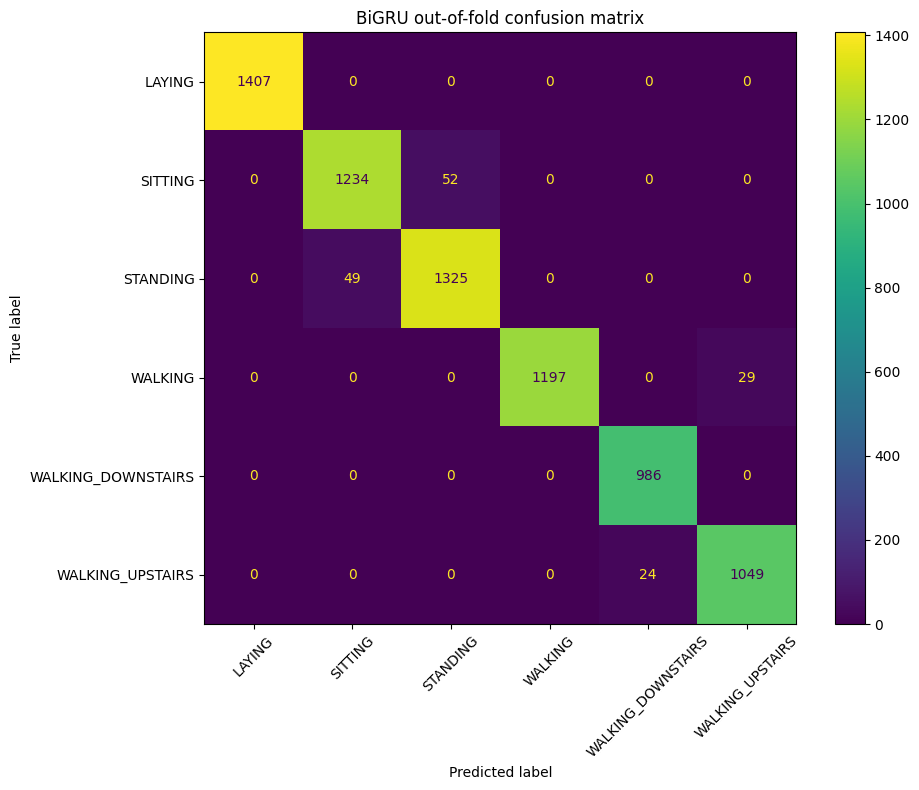

In [15]:
if USE_TEMPORAL_FOR_FINAL:
    selected_oof_predictions = temporal_oof_predictions
    selected_method_name = "Calibrated BiGRU plus temporal decoding"
else:
    selected_oof_predictions = base_oof_predictions
    selected_method_name = "Calibrated BiGRU probabilities"

selected_oof_metrics = calculate_metrics(
    y,
    selected_oof_predictions,
)

print("Selected method:", selected_method_name)
print(json.dumps(selected_oof_metrics, indent=2))

report_text = classification_report(
    y,
    selected_oof_predictions,
    target_names=CLASS_NAMES,
    digits=5,
    zero_division=0,
)
print(report_text)

with open(
    OUTPUT_DIR / "oof_classification_report.txt",
    "w",
) as file:
    file.write(report_text)

report_dictionary = classification_report(
    y,
    selected_oof_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
per_class_report_df = pd.DataFrame(report_dictionary).transpose()
per_class_report_df.to_csv(
    OUTPUT_DIR / "oof_per_class_metrics.csv"
)
display(per_class_report_df)

matrix = confusion_matrix(y, selected_oof_predictions)
display_object = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)
fig, ax = plt.subplots(figsize=(10, 8))
display_object.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)
plt.title("BiGRU out-of-fold confusion matrix")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "oof_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 13. Decode test rows and create the Kaggle submission CSV


In [16]:
non_temporal_test_prediction_ids = np.argmax(
    calibrated_test_probabilities,
    axis=1,
)

all_training_indices = np.arange(len(y), dtype=np.int64)
full_transition_matrix, full_initial_probability = estimate_transition_model(
    y,
    subjects,
    raw_order_train,
    all_training_indices,
    laplace=0.10,
)

temporal_test_prediction_ids = np.empty(
    len(test_df),
    dtype=np.int64,
)

for subject_id in np.unique(test_subjects):
    subject_indices = np.flatnonzero(test_subjects == subject_id)
    ordered_indices = subject_indices[
        np.argsort(raw_order_test[subject_indices])
    ]
    temporal_test_prediction_ids[ordered_indices] = viterbi_decode(
        calibrated_test_probabilities[ordered_indices],
        full_transition_matrix,
        full_initial_probability,
        BEST_TRANSITION_STRENGTH,
    )

if USE_TEMPORAL_FOR_FINAL:
    final_test_prediction_ids = temporal_test_prediction_ids
else:
    final_test_prediction_ids = non_temporal_test_prediction_ids


def create_submission(prediction_ids, output_path):
    prediction_labels = label_encoder.inverse_transform(prediction_ids)

    if sample_submission_df is not None:
        submission = sample_submission_df.copy()
        if len(submission) != len(prediction_labels):
            raise ValueError(
                "Sample submission row count does not match the predictions."
            )

        if TARGET_COLUMN in submission.columns:
            submission_target_column = TARGET_COLUMN
        else:
            id_like = {
                "id",
                "index",
                "sample_id",
                "row_id",
            }
            target_candidates = [
                column for column in submission.columns
                if str(column).lower() not in id_like
            ]
            if len(target_candidates) != 1:
                raise ValueError(
                    "Could not identify exactly one prediction column in "
                    "sample_submission.csv."
                )
            submission_target_column = target_candidates[0]

        submission[submission_target_column] = prediction_labels
    else:
        if TEST_ID_COLUMN is not None:
            submission_ids = test_df[TEST_ID_COLUMN].to_numpy()
        else:
            submission_ids = np.arange(len(prediction_labels))

        submission = pd.DataFrame({
            TEST_ID_COLUMN if TEST_ID_COLUMN is not None else "id": submission_ids,
            TARGET_COLUMN: prediction_labels,
        })

    submission.to_csv(output_path, index=False)
    return submission


FINAL_SUBMISSION_PATH = Path(
    "/kaggle/working/submission_bigru_macro_f1.csv"
)
FALLBACK_SUBMISSION_PATH = Path(
    "/kaggle/working/submission_bigru_no_temporal.csv"
)

final_submission = create_submission(
    final_test_prediction_ids,
    FINAL_SUBMISSION_PATH,
)
fallback_submission = create_submission(
    non_temporal_test_prediction_ids,
    FALLBACK_SUBMISSION_PATH,
)

final_submission.to_csv(
    OUTPUT_DIR / FINAL_SUBMISSION_PATH.name,
    index=False,
)
fallback_submission.to_csv(
    OUTPUT_DIR / FALLBACK_SUBMISSION_PATH.name,
    index=False,
)

print("Final submission:", FINAL_SUBMISSION_PATH)
print("Fallback submission:", FALLBACK_SUBMISSION_PATH)
print("Final submission shape:", final_submission.shape)
print("Missing values:")
print(final_submission.isnull().sum())
print("Prediction distribution:")
print(final_submission.iloc[:, -1].value_counts())
display(final_submission.head())
display(final_submission.tail())


Final submission: /kaggle/working/submission_bigru_macro_f1.csv
Fallback submission: /kaggle/working/submission_bigru_no_temporal.csv
Final submission shape: (2947, 2)
Missing values:
id          0
Activity    0
dtype: int64
Prediction distribution:
Activity
STANDING              574
LAYING                537
WALKING               496
SITTING               449
WALKING_UPSTAIRS      447
WALKING_DOWNSTAIRS    444
Name: count, dtype: int64


,id,Activity
0,1,STANDING
1,2,STANDING
2,3,STANDING
3,4,STANDING
4,5,STANDING


,id,Activity
2942,2943,WALKING_UPSTAIRS
2943,2944,WALKING_UPSTAIRS
2944,2945,WALKING_UPSTAIRS
2945,2946,WALKING_UPSTAIRS
2946,2947,WALKING_UPSTAIRS


## 14. Save probabilities and run metadata


In [17]:
np.save(OUTPUT_DIR / "oof_activity_probabilities.npy", oof_activity)
np.save(OUTPUT_DIR / "oof_hierarchical_probabilities.npy", oof_hierarchical)
np.save(
    OUTPUT_DIR / "calibrated_oof_probabilities.npy",
    calibrated_oof_probabilities,
)
np.save(
    OUTPUT_DIR / "calibrated_test_probabilities.npy",
    calibrated_test_probabilities,
)

run_summary = {
    "model_type": MODEL_TYPE,
    "model_name": "DeepConv BiGRU hybrid multi-head ensemble",
    "run_mode": RUN_MODE,
    "training_seeds": TRAINING_SEEDS,
    "folds": N_FOLDS,
    "cross_validation": CV_NAME,
    "raw_signal_channels": RAW_SIGNAL_NAMES,
    "expanded_sequence_channels": int(X_sequence.shape[2]),
    "engineered_feature_count": len(feature_columns),
    "competition_metric": "multiclass Macro F1",
    "best_hierarchy_alpha": BEST_HIERARCHY_ALPHA,
    "class_probability_factors": {
        class_name: float(factor)
        for class_name, factor in zip(
            CLASS_NAMES,
            CLASS_PROBABILITY_FACTORS,
        )
    },
    "base_oof_macro_f1": float(base_oof_macro_f1),
    "temporal_oof_macro_f1": float(temporal_oof_macro_f1),
    "selected_oof_metrics": selected_oof_metrics,
    "best_transition_strength": float(BEST_TRANSITION_STRENGTH),
    "temporal_selected": bool(USE_TEMPORAL_FOR_FINAL),
    "cross_validation_seconds": float(cross_validation_seconds),
    "final_submission_path": str(FINAL_SUBMISSION_PATH),
    "fallback_submission_path": str(FALLBACK_SUBMISSION_PATH),
    "hidden_test_labels_used": False,
}

with open(OUTPUT_DIR / "run_summary.json", "w") as file:
    json.dump(run_summary, file, indent=2)

print(json.dumps(run_summary, indent=2))
print("Generated files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)


{
  "model_type": "GRU",
  "model_name": "DeepConv BiGRU hybrid multi-head ensemble",
  "run_mode": "final",
  "training_seeds": [
    42,
    2026
  ],
  "folds": 5,
  "cross_validation": "StratifiedGroupKFold by subject",
  "raw_signal_channels": [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
  ],
  "expanded_sequence_channels": 24,
  "engineered_feature_count": 561,
  "competition_metric": "multiclass Macro F1",
  "best_hierarchy_alpha": 0.9000000000000004,
  "class_probability_factors": {
    "LAYING": 1.0,
    "SITTING": 1.0700000000000003,
    "STANDING": 1.0,
    "WALKING": 1.1,
    "WALKING_DOWNSTAIRS": 1.06,
    "WALKING_UPSTAIRS": 0.9
  },
  "base_oof_macro_f1": 0.9637753013870173,
  "temporal_oof_macro_f1": 0.979223130796688,
  "selected_oof_metrics": {
    "accuracy": 0.9790533188248096,
    "macro_precision": 0.9788968270733734,
    "macro_recall": 0.97